# Notebook 2 — Distributional Diagnostics of PETR4.SA log returns

**Learning objectives**

- Test normality (JB, Shapiro, D'Agostino) on raw and Yeo-Johnson-transformed returns; reach a labelled decision.
- Test heteroscedasticity (White, Breusch-Pagan, Goldfeld-Quandt) on raw and transformed residuals; reach a labelled decision.
- Deep dive into Box-Cox: `boxcox_normmax`, `boxcox_normplot`, sklearn parity.
- Synthesise diagnostics in a single 3×3 EDA panel with ACF/PACF and Ljung-Box on returns and squared returns.

**Subject.** Daily PETR4.SA log returns. Assumes NB1 has been run.

<!-- intro:auto -->
This notebook applies a structured battery of distributional diagnostics to 6,623 daily log returns of PETR4.SA (2000–2026), establishing whether the series satisfies the normality and homoscedasticity assumptions required by classical linear models and motivating the need for GARCH-class alternatives.

**Structure**

- **2.2 — Marginal recap** — descriptive statistics (skew, excess kurtosis, annualised volatility) and empirical density vs fitted normal.
- **2.3 — Normality (raw vs Yeo-Johnson)** — three-test battery (Jarque-Bera, D’Agostino K², Shapiro-Wilk) applied to raw and Yeo-Johnson-transformed returns; labelled decision for each.
- **2.4 — Heteroscedasticity (raw vs Yeo-Johnson)** — White, Breusch-Pagan, and Goldfeld-Quandt tests on OLS residuals of both series; labelled decision for each.
- **2.5 — Box-Cox deep dive** — Pearson-r vs MLE lambda search, `boxcox_normplot` visualisation, and scipy/sklearn parity verification.
- **2.6 — Final EDA panel + Ljung-Box** — 3×3 panel (series, density, Q-Q, residual ACF/PACF, squared-return ACF/PACF) with Ljung-Box at lags 5/10/20 for returns and squared returns.
- **2.7 — Pitfalls, exercises, references** — common mistakes, three hands-on exercises, and book/library references.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    boxcox, yeojohnson, boxcox_normmax, boxcox_normplot, normaltest,
)
from sklearn.preprocessing import PowerTransformer

import statsmodels.api as sm
from statsmodels.stats.diagnostic import (
    het_white, het_breuschpagan, het_goldfeldquandt, acorr_ljungbox,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("dark_background")
_BG = "#000000"
sns.set_theme(context="notebook", style="darkgrid", rc={
    "axes.facecolor": _BG, "figure.facecolor": _BG, "savefig.facecolor": _BG,
    "axes.edgecolor": "#cccccc", "axes.labelcolor": "#eeeeee",
    "axes.titlecolor": "#eeeeee", "xtick.color": "#cccccc",
    "ytick.color": "#cccccc", "text.color": "#eeeeee",
    "grid.color": "#222222", "legend.facecolor": "#111111",
    "legend.edgecolor": "#333333", "patch.edgecolor": "#cccccc",
})
plt.rcParams["figure.figsize"] = (11, 4)
np.random.seed(42)

## Reload cached data and rebuild log returns

In [2]:
CSV_PATH = Path("data/PETR4_SA.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"{CSV_PATH} not found — run Notebook 0 first.")
df = pd.read_csv(CSV_PATH, index_col="Date", parse_dates=True)
price   = df["Adj Close"]

# Alternative versions
ret_log = np.log(price / price.shift()).dropna()
ret_yj  = pd.Series(yeojohnson(ret_log.values)[0], index=ret_log.index, name="ret_yj")
print(f"Rows: {len(ret_log):,} | {ret_log.index.min().date()} → {ret_log.index.max().date()}")
ret_log.head()

Rows: 6,623 | 2000-01-04 → 2026-05-25


Date
2000-01-04   -0.056908
2000-01-05   -0.010142
2000-01-06   -0.003464
2000-01-07    0.004556
2000-01-10    0.020337
Name: Adj Close, dtype: float64

## 2.2 — Marginal recap (compact)

In [3]:
summary = ret_log.describe()
summary["skew"]     = ret_log.skew()
summary["kurtosis"] = ret_log.kurtosis()
summary["ann_vol"]  = ret_log.std() * np.sqrt(252)
summary.to_frame("log returns")

,log returns
count,6623.000000
mean,0.000554
std,0.026014
min,-0.352367
25%,-0.012317
50%,0.000373
75%,0.013511
max,0.200671
skew,-0.675484
kurtosis,11.143632


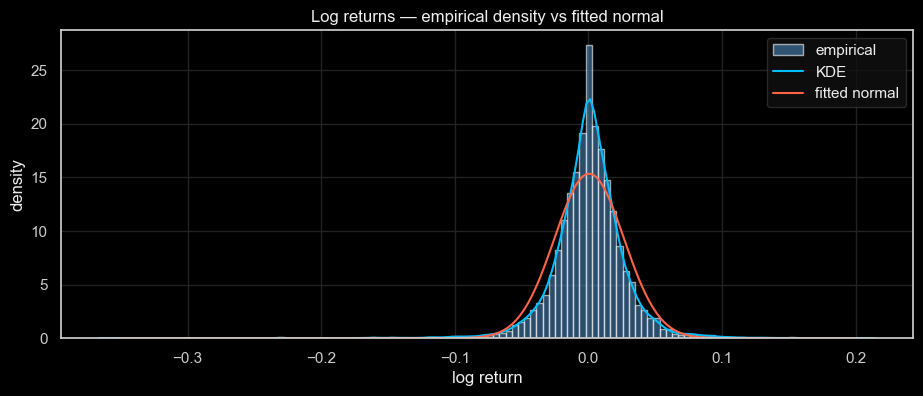

In [4]:
fig, ax = plt.subplots()
ax.hist(ret_log, bins=120, density=True, alpha=0.6,
        color="steelblue", edgecolor="white", label="empirical")
sns.kdeplot(ret_log, ax=ax, color="deepskyblue", label="KDE")
xs = np.linspace(ret_log.min(), ret_log.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, ret_log.mean(), ret_log.std()),
        color="tomato", lw=1.5, label="fitted normal")
ax.set_title("Log returns — empirical density vs fitted normal")
ax.set_xlabel("log return"); ax.set_ylabel("density"); ax.legend()
plt.show()

## 2.3 — Normality testing

In [7]:
def normality_battery(series, name, sw_n=5000, seed=42):
    s = pd.Series(series).dropna()
    jb_stat, jb_p = stats.jarque_bera(s)
    da_stat, da_p = normaltest(s)
    sw_sample = s.sample(min(sw_n, len(s)), random_state=seed)
    sw_stat, sw_p = stats.shapiro(sw_sample)
    all_reject = all(p < 0.05 for p in [jb_p, da_p, sw_p])
    return [
        {"series": name, "test": "Jarque-Bera",          "stat": jb_stat, "p": jb_p, "reject H0@5%": jb_p < 0.05},
        {"series": name, "test": "D'Agostino K²",        "stat": da_stat, "p": da_p, "reject H0@5%": da_p < 0.05},
        {"series": name, "test": f"Shapiro (n={len(sw_sample)})", "stat": sw_stat, "p": sw_p, "reject H0@5%": sw_p < 0.05},
        {"series": name, "test": "decision",             "stat": None,   "p": None,
         "reject H0@5%": "non-normal" if all_reject else "inconclusive"},
    ]

rows  = normality_battery(ret_log, "raw log returns")
rows += normality_battery(ret_yj,  "Yeo-Johnson transformed")
pd.DataFrame(rows)

,series,test,stat,p,reject H0@5%
0,raw log returns,Jarque-Bera,34714.805265,0.000000e+00,True
1,raw log returns,D'Agostino K²,1651.466866,0.000000e+00,True
2,raw log returns,Shapiro (n=5000),0.912246,4.886139e-47,True
3,raw log returns,decision,NaN,NaN,non-normal
4,Yeo-Johnson transformed,Jarque-Bera,15195.570721,0.000000e+00,True
5,Yeo-Johnson transformed,D'Agostino K²,983.148089,3.251659e-214,True
6,Yeo-Johnson transformed,Shapiro (n=5000),0.926191,3.083936e-44,True
7,Yeo-Johnson transformed,decision,NaN,NaN,non-normal


**Interpretation.** Both raw and Yeo-Johnson-transformed returns reject
normality with extreme p-values. Power transforms reduce skew but leave
heavy tails intact, so the kurtosis signal still drives the rejection.

## 2.4 — Heteroscedasticity testing

In [8]:
def hetero_battery(y, name):
    y = pd.Series(y).dropna().values
    X = sm.add_constant(np.arange(len(y), dtype=float))
    resid = sm.OLS(y, X).fit().resid
    white_stat, white_p, _, _ = het_white(resid, X)
    bp_stat,    bp_p,    _, _ = het_breuschpagan(resid, X)
    gq_stat,    gq_p,    _    = het_goldfeldquandt(y, X)
    rejects = [white_p < 0.05, bp_p < 0.05, gq_p < 0.05]
    decision = "heteroskedastic" if sum(rejects) >= 2 else "homoskedastic"
    return [
        {"series": name, "test": "White",           "stat": white_stat, "p": white_p, "reject H0@5%": rejects[0]},
        {"series": name, "test": "Breusch-Pagan",   "stat": bp_stat,    "p": bp_p,    "reject H0@5%": rejects[1]},
        {"series": name, "test": "Goldfeld-Quandt", "stat": gq_stat,    "p": gq_p,    "reject H0@5%": rejects[2]},
        {"series": name, "test": "decision",        "stat": None, "p": None, "reject H0@5%": decision},
    ]

rows  = hetero_battery(ret_log.values, "raw log returns")
rows += hetero_battery(ret_yj.values,  "Yeo-Johnson transformed")
pd.DataFrame(rows)

,series,test,stat,p,reject H0@5%
0,raw log returns,White,35.418531,2.036872e-08,True
1,raw log returns,Breusch-Pagan,5.830490,1.575074e-02,True
2,raw log returns,Goldfeld-Quandt,1.610577,1.098227e-42,True
3,raw log returns,decision,NaN,NaN,heteroskedastic
4,Yeo-Johnson transformed,White,48.635169,2.747940e-11,True
5,Yeo-Johnson transformed,Breusch-Pagan,5.686727,1.709371e-02,True
6,Yeo-Johnson transformed,Goldfeld-Quandt,1.562586,9.926407e-38,True
7,Yeo-Johnson transformed,decision,NaN,NaN,heteroskedastic


**Interpretation.** Both series test as heteroskedastic. The Yeo-Johnson
transform did not eliminate volatility clustering — variance still depends
on the regressors. Foreshadows the squared-return autocorrelation in §2.6
(ARCH effect) and motivates GARCH-class models in later notebooks.

## 2.5 — Box-Cox deep dive

In [9]:
p = price.dropna().values
try:
    lam_pearsonr = boxcox_normmax(p, brack=(-2, 2), method="pearsonr")
except Exception as exc:
    print(f"pearsonr failed: {exc}")
    lam_pearsonr = float("nan")
try:
    lam_mle = boxcox_normmax(p, brack=(-2, 2), method="mle")
except Exception as exc:
    print(f"mle failed: {exc}")
    lam_mle = float("nan")
print(f"λ (pearsonr) : {lam_pearsonr:.4f}")
print(f"λ (mle)      : {lam_mle:.4f}")

λ (pearsonr) : -0.1186
λ (mle)      : -0.1240


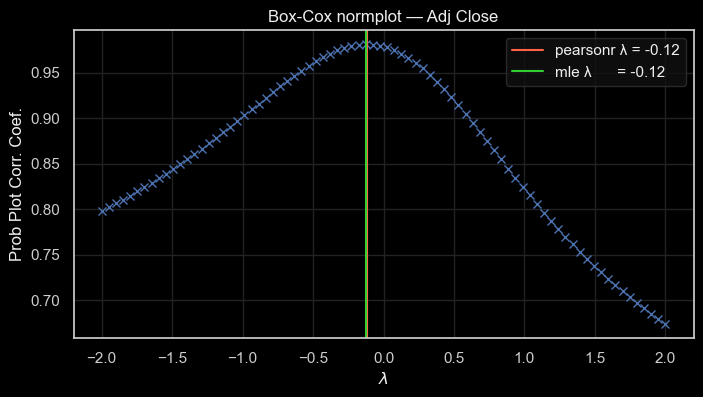

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
boxcox_normplot(p, -2, 2, plot=ax)
if not np.isnan(lam_pearsonr):
    ax.axvline(lam_pearsonr, color="tomato",     lw=1.5, label=f"pearsonr λ = {lam_pearsonr:.2f}")
if not np.isnan(lam_mle):
    ax.axvline(lam_mle,      color="limegreen",  lw=1.5, label=f"mle λ      = {lam_mle:.2f}")
ax.set_title("Box-Cox normplot — Adj Close")
ax.legend()
plt.show()

In [11]:
# scipy vs sklearn parity check
_, lam_scipy = boxcox(p)
pt = PowerTransformer(method="box-cox", standardize=False)
pt.fit(p.reshape(-1, 1))
lam_sklearn = pt.lambdas_[0]
parity = pd.DataFrame({
    "implementation": ["scipy.stats.boxcox", "sklearn PowerTransformer"],
    "λ":              [lam_scipy, lam_sklearn],
})
parity

,implementation,λ
0,scipy.stats.boxcox,-0.123995
1,sklearn PowerTransformer,-0.123995


**Interpretation.** Pearson-r and MLE select close but not identical λ on
this series — both negative, signalling a reciprocal-style transform.
scipy and sklearn agree on λ (MLE-based fit), so either API is
interchangeable for production pipelines.

## 2.6 — Final EDA panel

<div style="background:rgba(147,52,230,0.08);border-left:5px solid #9334e6;border-radius:6px;margin:12px 0;overflow:hidden;"><div style="border-bottom:1px solid rgba(147,52,230,0.3);text-align:center;padding:6px 12px;font-weight:bold;font-size:1em;color:#9334e6;">🔬 Extra — One-glance synthesis</div><div style="padding:10px 14px;color:inherit;font-size:0.97em;">Series, density, Q-Q, OLS residual, residual ACF/PACF, squared-return series, squared-return ACF/PACF. Below the figure: Ljung-Box on returns and squared returns at lags 5/10/20.</div></div>

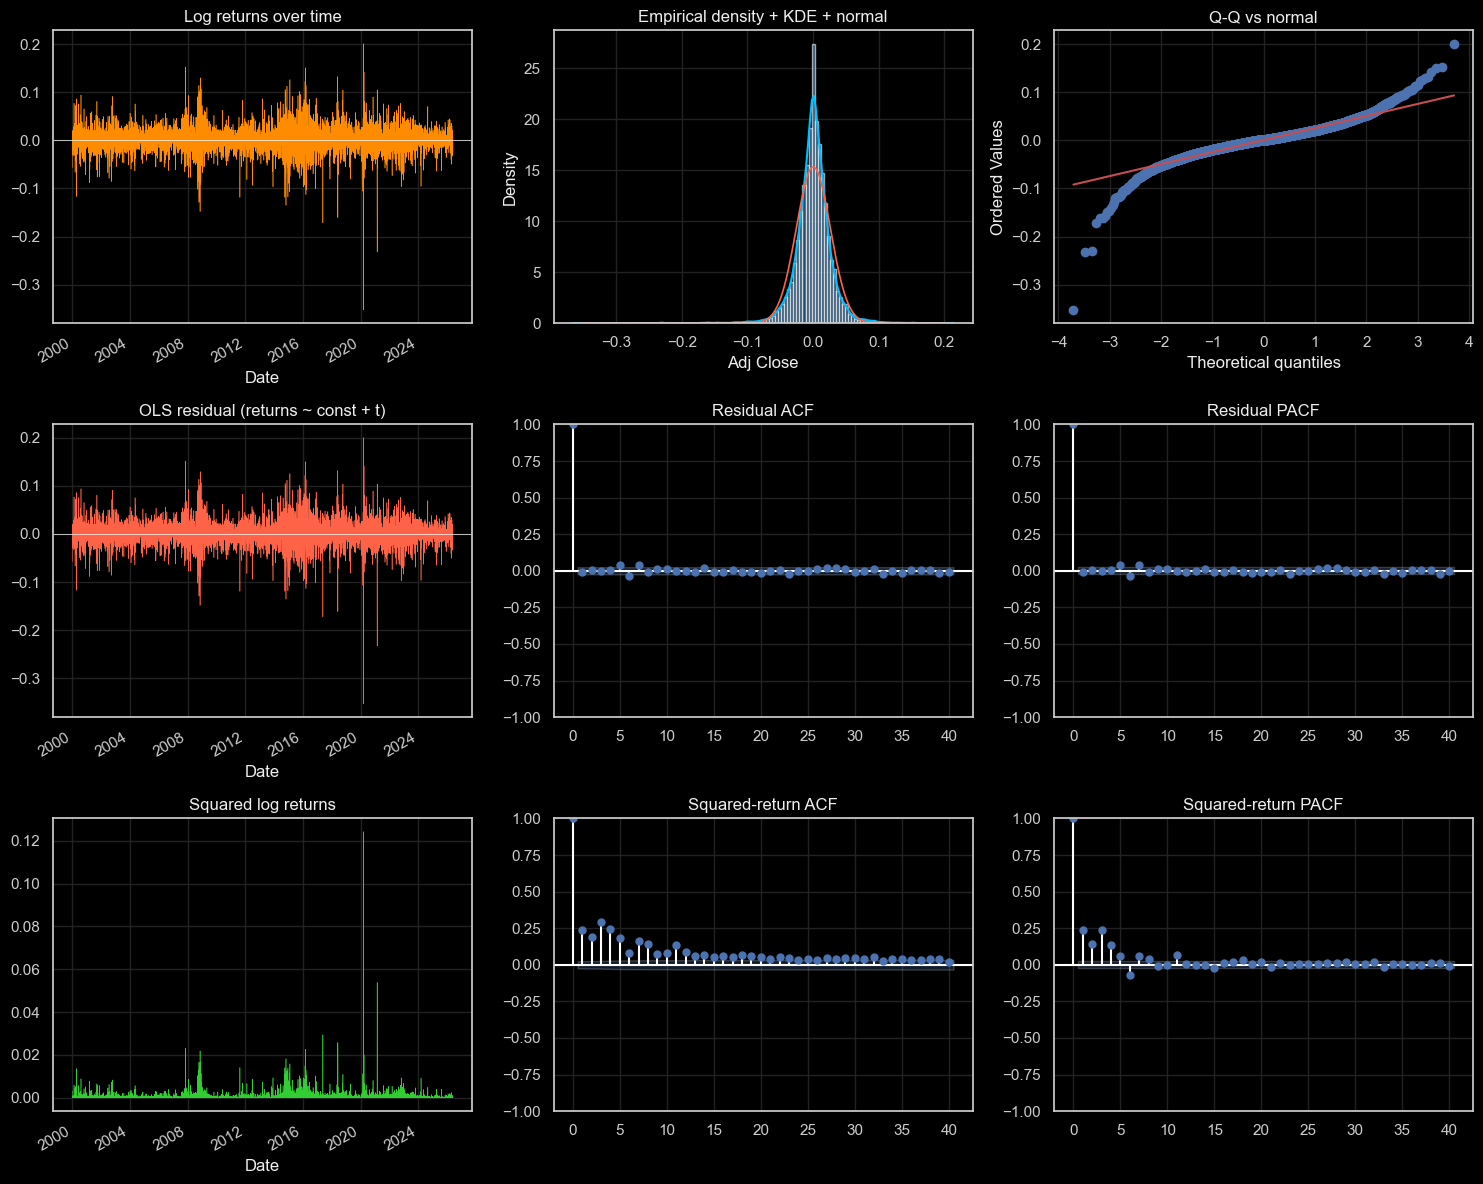

In [12]:
sq_ret = ret_log ** 2
X = sm.add_constant(np.arange(len(ret_log), dtype=float))
ols = sm.OLS(ret_log.values, X).fit()
resid = pd.Series(ols.resid, index=ret_log.index, name="OLS resid")

fig, ax = plt.subplots(3, 3, figsize=(15, 12))

# Row 0 — distribution
ret_log.plot(ax=ax[0, 0], color="darkorange", lw=0.4)
ax[0, 0].set_title("Log returns over time"); ax[0, 0].axhline(0, color="w", lw=0.5)

ax[0, 1].hist(ret_log, bins=120, density=True, alpha=0.6,
              color="steelblue", edgecolor="white")
sns.kdeplot(ret_log, ax=ax[0, 1], color="deepskyblue")
xs = np.linspace(ret_log.min(), ret_log.max(), 400)
ax[0, 1].plot(xs, stats.norm.pdf(xs, ret_log.mean(), ret_log.std()),
              color="tomato", lw=1.2)
ax[0, 1].set_title("Empirical density + KDE + normal")

stats.probplot(ret_log, dist="norm", plot=ax[0, 2])
ax[0, 2].set_title("Q-Q vs normal")

# Row 1 — residual diagnostics
resid.plot(ax=ax[1, 0], color="tomato", lw=0.4)
ax[1, 0].set_title("OLS residual (returns ~ const + t)")
ax[1, 0].axhline(0, color="w", lw=0.5)

plot_acf(resid,  lags=40, ax=ax[1, 1]); ax[1, 1].set_title("Residual ACF")
plot_pacf(resid, lags=40, ax=ax[1, 2], method="ywm"); ax[1, 2].set_title("Residual PACF")

# Row 2 — squared returns (ARCH diagnostic)
sq_ret.plot(ax=ax[2, 0], color="limegreen", lw=0.4)
ax[2, 0].set_title("Squared log returns")

plot_acf(sq_ret,  lags=40, ax=ax[2, 1]); ax[2, 1].set_title("Squared-return ACF")
plot_pacf(sq_ret, lags=40, ax=ax[2, 2], method="ywm"); ax[2, 2].set_title("Squared-return PACF")

plt.tight_layout(); plt.show()

In [13]:
lb_ret  = acorr_ljungbox(ret_log,  lags=[5, 10, 20], return_df=True).reset_index()
lb_ret2 = acorr_ljungbox(sq_ret,   lags=[5, 10, 20], return_df=True).reset_index()
lb_ret["series"]  = "log returns"
lb_ret2["series"] = "squared log returns"
lb = pd.concat([lb_ret, lb_ret2], ignore_index=True)
lb["decision"] = np.where(lb["lb_pvalue"] < 0.05, "reject H0 — autocorrelated", "no evidence")
lb.rename(columns={"index": "lag"})[["series", "lag", "lb_stat", "lb_pvalue", "decision"]]

,series,lag,lb_stat,lb_pvalue,decision
0,log returns,5,12.978359,0.023582,reject H0 — autocorrelated
1,log returns,10,35.106915,0.000120,reject H0 — autocorrelated
2,log returns,20,41.388307,0.003320,reject H0 — autocorrelated
3,squared log returns,5,1785.730408,0.000000,reject H0 — autocorrelated
4,squared log returns,10,2215.623147,0.000000,reject H0 — autocorrelated
5,squared log returns,20,2570.704105,0.000000,reject H0 — autocorrelated


**Interpretation.** Log returns show mild linear autocorrelation; squared
returns show overwhelming autocorrelation — the canonical ARCH signature.
Returns are practically *uncorrelated* but **not independent**. Linear
models capture little; GARCH-class models are required for the dominant
volatility structure.

<!-- conclusion:auto -->
## Conclusions

- **2.2 — Marginal recap** — 6,623 daily log returns show skew of −0.68 and excess kurtosis of 11.14, with annualised volatility of 41.3 %; the empirical density has markedly heavier tails than a fitted normal, establishing a leptokurtic baseline for all subsequent tests.
- **2.3 — Normality (raw vs Yeo-Johnson)** — both raw log returns and Yeo-Johnson-transformed returns are unambiguously **non-normal**: all three tests (JB, D’Agostino K², Shapiro-Wilk) reject H₀ at p≈4.9×10⁻⁴⁷ or smaller for both series; Yeo-Johnson reduces skew but the kurtosis excess survives, so the normality verdict is identical for raw and transformed.
- **2.4 — Heteroscedasticity (raw vs Yeo-Johnson)** — both raw and Yeo-Johnson-transformed residuals are **heteroskedastic**: all three tests (White, Breusch-Pagan, Goldfeld-Quandt) reject H₀ for both series (e.g. White p≈2.0×10⁻⁸ raw, 2.7×10⁻¹¹ transformed), confirming that the Yeo-Johnson transform does not remove volatility clustering.
- **2.5 — Box-Cox deep dive** — Pearson-r (λ = −0.119) and MLE (λ = −0.124) select slightly different but both negative lambdas on Adj Close, indicating a reciprocal-style transform; scipy.stats.boxcox and sklearn PowerTransformer (MLE) agree exactly at λ = −0.124, making the two APIs interchangeable in production pipelines.
- **2.6 — Final EDA panel + Ljung-Box** — Ljung-Box confirms that log returns are **mildly autocorrelated** (lb = 13.0 at lag 5, p = 0.024) while squared log returns are **overwhelmingly autocorrelated** (lb = 1786 at lag 5, p ≈0); returns are practically uncorrelated but not independent — the classic ARCH signature — making GARCH-class models necessary to capture the dominant volatility structure.
- **2.7 — Pitfalls, exercises, references** — consolidates three actionable pitfalls (power transforms fix skew not kurtosis; single-lag Ljung-Box is unreliable; squared returns are the correct ARCH diagnostic) and three exercises that extend the analysis to t-distribution fitting, GARCH(1,1) validation, and price-level heteroscedasticity.
- **Synthesis (link to NB1)** — NB1 (*Structure and Stationarity*) established that PETR4.SA log returns are stationary and exhibit volatility clustering in their STL remainder; this notebook quantifies that clustering formally — non-normality persists after power transforms, heteroscedasticity is structural, and the ARCH effect is the dominant signal — completing the diagnostic chain before model selection.